Загрузка данных...

Обучение моделей...

СРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТЕ:
Модель                    |   Accuracy |   F1-Score
----------------------------------------------------
Logistic Regression       |     0.9860 |     0.9889
SVM (linear)              |     0.9860 |     0.9889
Decision Tree             |     0.9371 |     0.9503


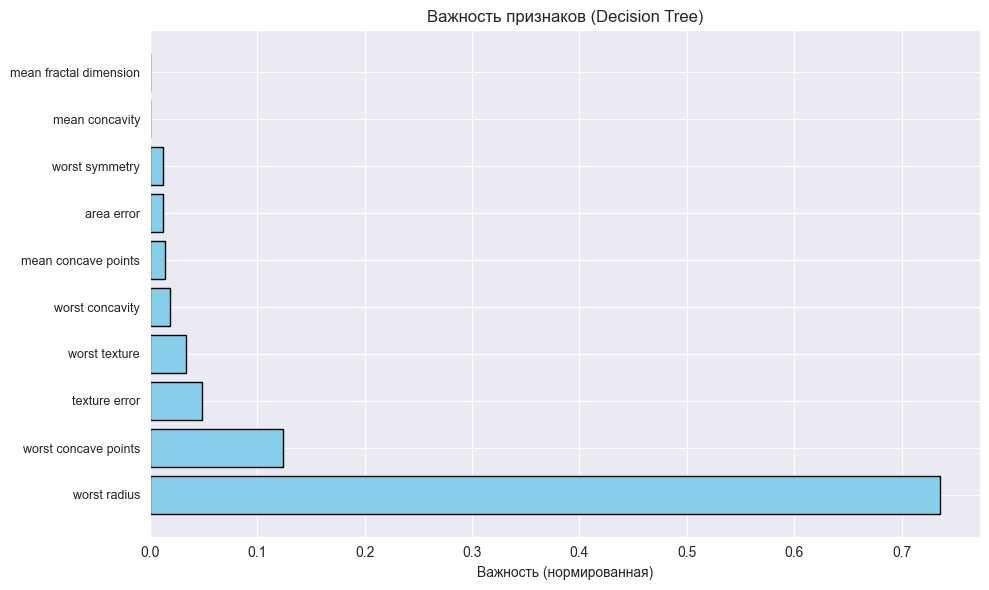

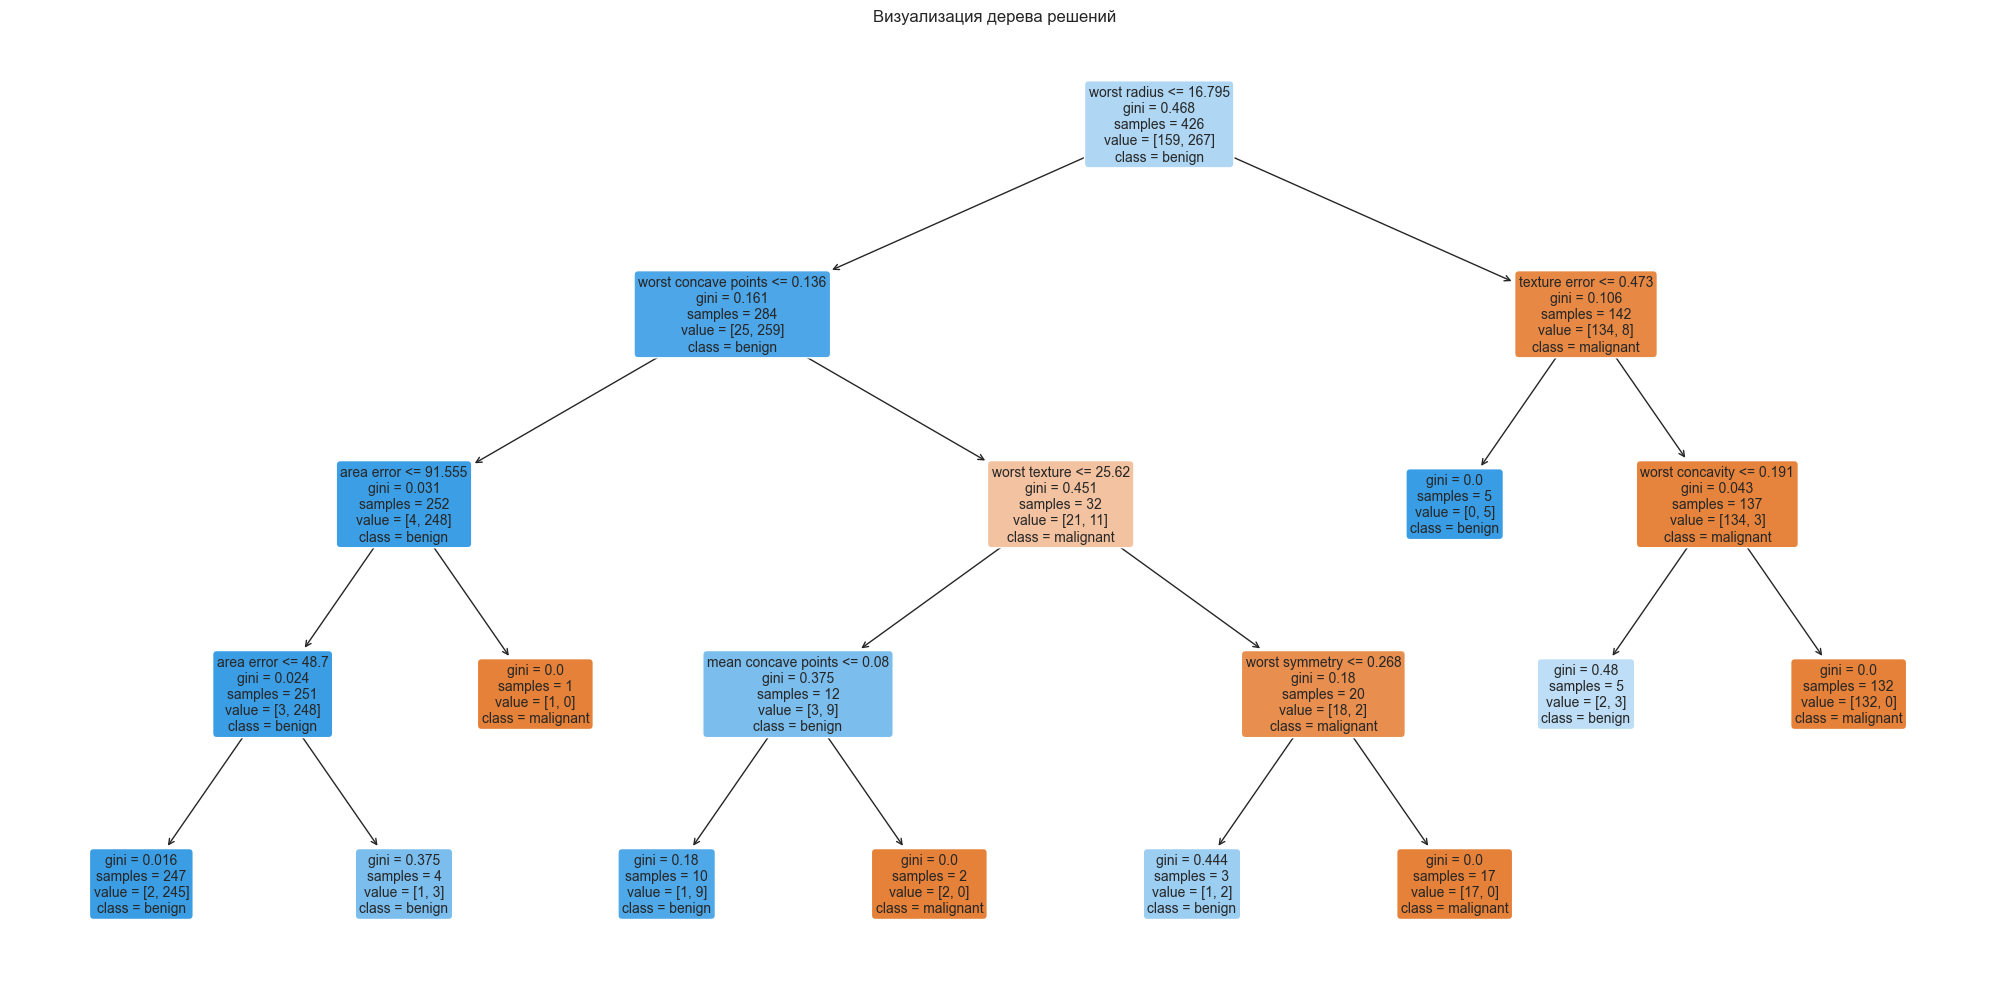


Правила дерева решений (первые 50 строк):
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- area error <= 48.70
|   |   |   |   |--- class: 1
|   |   |   |--- area error >  48.70
|   |   |   |   |--- class: 1
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- mean concave points <= 0.08
|   |   |   |   |--- class: 1
|   |   |   |--- mean concave points >  0.08
|   |   |   |  


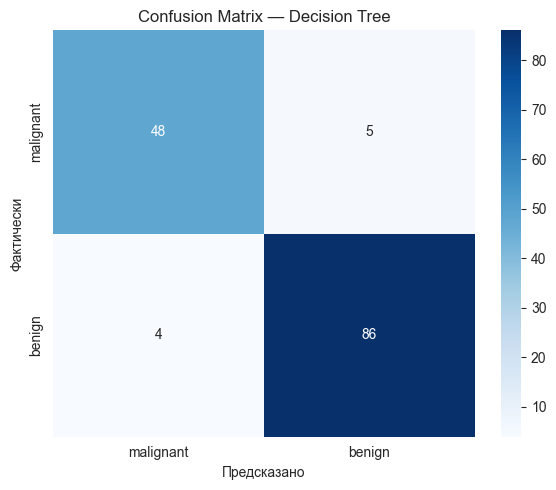

In [5]:
# !pip install scikit-learn pandas matplotlib seaborn graphviz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Выбор датасета (можно заменить на load_iris() или свой CSV)
print("Загрузка данных...")
data = load_breast_cancer()  # 569 образцов, 30 признаков, бинарная классификация
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

# Предобработка (в этом датасете пропусков нет, но шаблон универсальный)
# Если есть пропуски:
# from sklearn.impute import SimpleImputer
# imputer = SimpleImputer(strategy='mean')
# X = imputer.fit_transform(X)

# Если есть категориальные признаки:
# from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# ... кодирование ...

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Масштабирование для линейных моделей и SVM (для дерева не обязательно, но делаем для единообразия)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение моделей
print("\nОбучение моделей...")

# • Логистическая регрессия
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# • SVM (с линейным ядром для интерпретируемости)
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# • Дерево решений (с ограничением глубины для читаемости)
tree_model = DecisionTreeClassifier(
    criterion='gini',      # или 'entropy'
    max_depth=4,           # ограничиваем глубину для визуализации
    min_samples_split=10,  # мин. объектов для разбиения
    random_state=42
)
tree_model.fit(X_train, y_train)  # дерево не требует масштабирования!
y_pred_tree = tree_model.predict(X_test)

# Оценка качества (две метрики: Accuracy + F1)
print("\nСРАВНЕНИЕ МОДЕЛЕЙ НА ТЕСТЕ:")
print(f"{'Модель':<25} | {'Accuracy':>10} | {'F1-Score':>10}")
print("-" * 52)
print(f"{'Logistic Regression':<25} | {accuracy_score(y_test, y_pred_log):>10.4f} | {f1_score(y_test, y_pred_log):>10.4f}")
print(f"{'SVM (linear)':<25} | {accuracy_score(y_test, y_pred_svm):>10.4f} | {f1_score(y_test, y_pred_svm):>10.4f}")
print(f"{'Decision Tree':<25} | {accuracy_score(y_test, y_pred_tree):>10.4f} | {f1_score(y_test, y_pred_tree):>10.4f}")

# Важность признаков (для дерева)
importances = tree_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # топ-10 признаков

plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Decision Tree)")
plt.barh(range(len(indices)), importances[indices][::-1], color='skyblue', edgecolor='black')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices][::-1], fontsize=9)
plt.xlabel("Важность (нормированная)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Визуализация дерева (вариант А: графическая)
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Визуализация дерева решений")
plt.tight_layout()
plt.show()

# Альтернатива (вариант Б: текстовые правила — удобно для отчёта)
print("\nПравила дерева решений (первые 50 строк):")
tree_rules = export_text(tree_model, feature_names=list(feature_names), max_depth=4)
print(tree_rules[:500])  # выводим часть, чтобы не заспамить консоль

# Бонус: матрица ошибок для лучшей модели
best_model_name = "Decision Tree"  # можно определить программно по метрикам
best_pred = y_pred_tree

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Предсказано")
plt.ylabel("Фактически")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()